In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("database.csv")

df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], format='%m/%d/%Y')

df = df.rename(columns={'Disaster Type': 'Incident type'})

df["year"] = df["Declaration Date"].dt.year

df["month"] = df["Declaration Date"].dt.month

df = df.dropna(subset=["Declaration Date", "State", "Incident type"]) # drop rows with missing values

print(df['Declaration Date'].isna().sum(), "missing dates found.")

df = df.drop_duplicates()

yearly_disasters=(df.groupby('year').size().reset_index(name='total_disasters'))

print(yearly_disasters.head())

0 missing dates found.
   year  total_disasters
0  1953               13
1  1954               17
2  1955               18
3  1956               16
4  1957               16


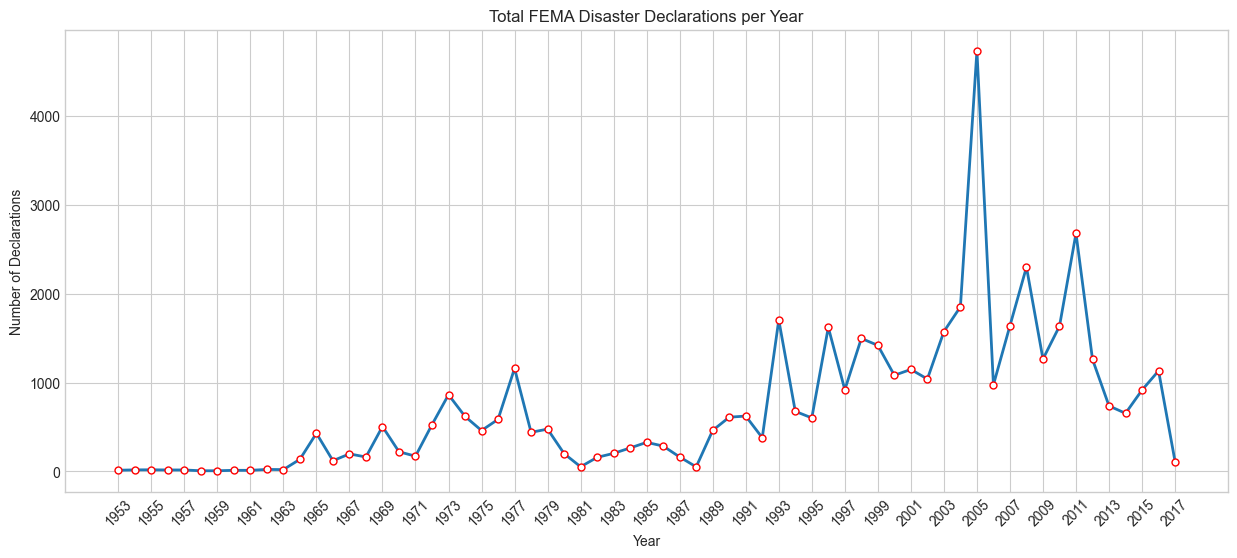

In [8]:
#yearly trend analysis

plt.figure(figsize=(15, 6))

plt.plot(
    yearly_disasters['year'],
    yearly_disasters['total_disasters'],
    marker='o',
    linewidth=2,
    markersize=5,
    markerfacecolor='white',
    markeredgecolor='#FF0000'
)

plt.xticks(yearly_disasters['year'][::2], rotation=45)
plt.title("Total FEMA Disaster Declarations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.grid(True)
plt.show()

1. Is there an increasing trend? 
    Yes. The graph shows a clear long-term upward trend in disaster declarations. Counts are very low in the early years (1950s–60s) and increase steadily from the 1970s onward, with consistently higher values after the 1990s.
2. Are there sudden spikes?
    Yes. A major spike is observed around 2005, which is the highest peak in the graph. Other noticeable spikes appear in the mid-1990s and late-2000s, indicating years with unusually high disaster activity.
3. Are there abnormal drops?
    Yes. Sharp drops occur immediately after peak years, especially following 2005. Smaller dips are also visible in the early 1980s and toward the final years, possibly due to lower activity or incomplete data.


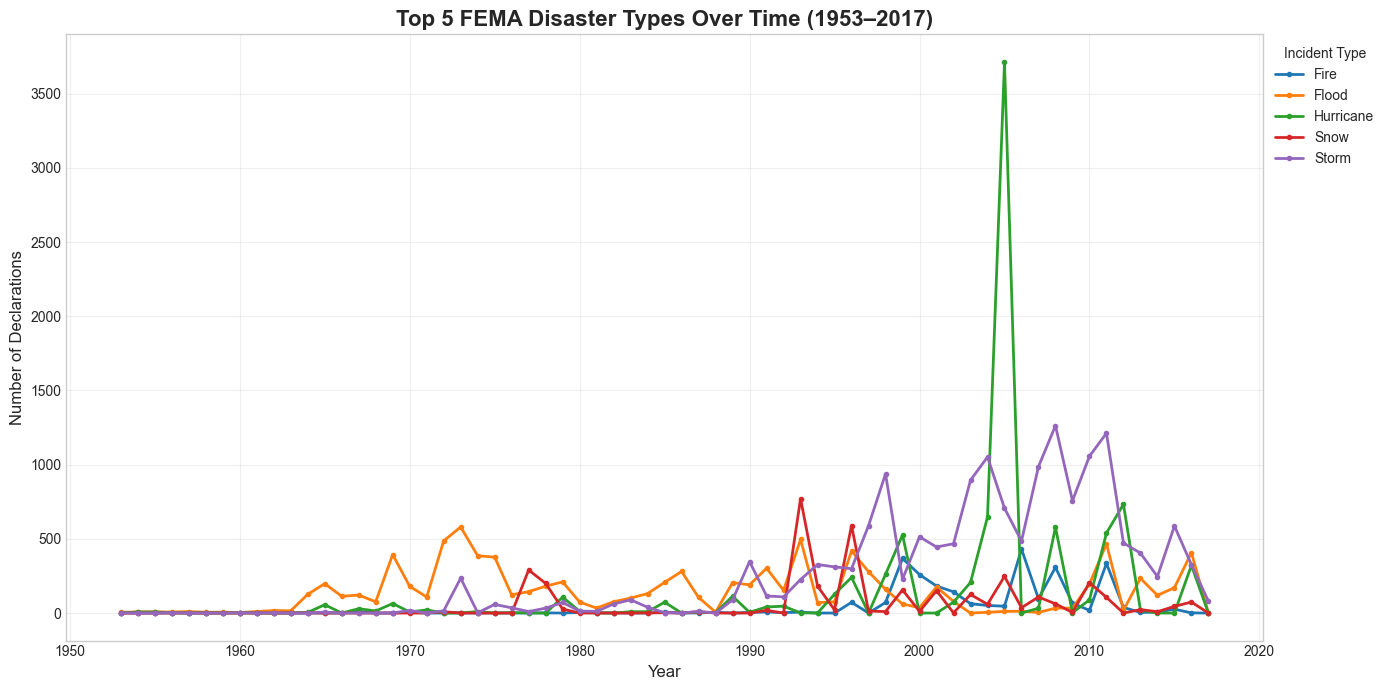

In [37]:
import matplotlib.pyplot as plt

# Get top 5 incident types
top_types = df["Incident type"].value_counts().nlargest(5).index
top_df = df[df["Incident type"].isin(top_types)]
top_pivot = top_df.groupby(["year", "Incident type"]).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(14, 7))

for col in top_pivot.columns:
    plt.plot(top_pivot.index, top_pivot[col], linewidth=2, marker='o', markersize=3, label=col)

plt.title("Top 5 FEMA Disaster Types Over Time (1953–2017)", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Declarations", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Incident Type", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Which disaster type is most frequent?
    Storms are the most frequent disaster type overall.
This is evident as the storm trend line remains consistently higher than other incident types for most years, especially from the late 1990s onward, indicating the largest number of declarations across time.

Which disaster type is increasing the fastest?
    Hurricanes show the fastest increase.
Although hurricanes are not consistently high every year, the graph shows sharp and dramatic spikes (notably in the mid-2000s), indicating rapid growth during extreme-event years compared to other incident types.

Is any disaster type declining?
No disaster type shows a clear long-term declining trend.
However , Snow and Fire remain relatively low and stable with occasional spikes. These types do not exhibit sustained growth like storms or hurricanes, but they also do not show consistent decline.

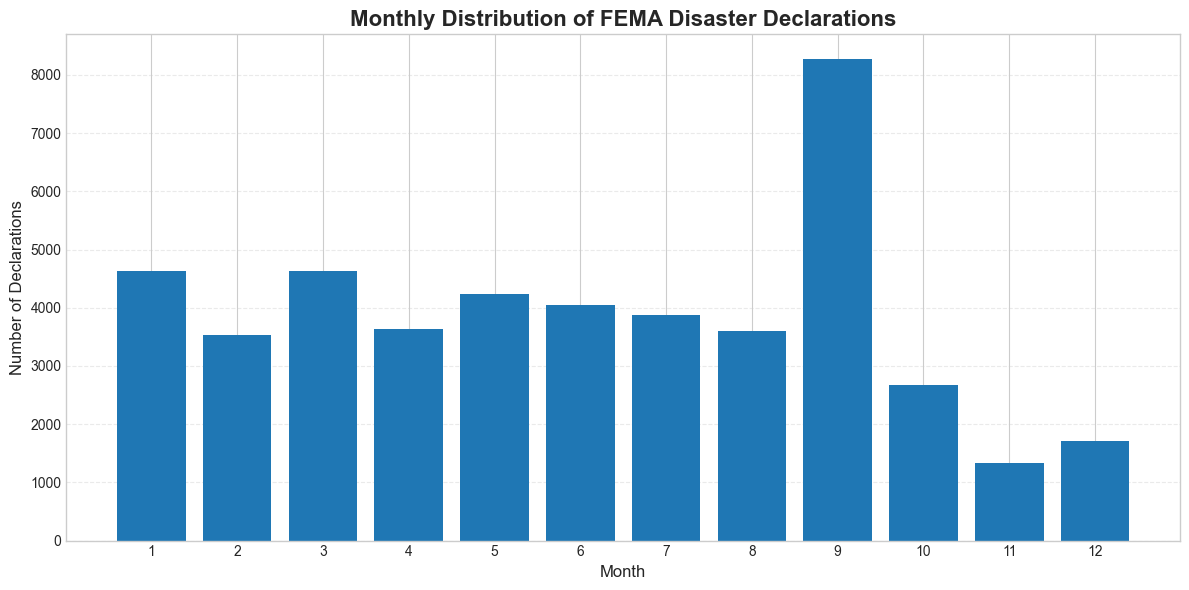

In [ ]:
import matplotlib.pyplot as plt

# Group by month
monthly_disasters = df.groupby('month').size()

# Sort by month number
monthly_disasters = monthly_disasters.sort_index()
plt.figure(figsize=(12,6))

plt.bar(monthly_disasters.index, monthly_disasters.values)

plt.title("Monthly Distribution of FEMA Disaster Declarations",
          fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Declarations", fontsize=12)

plt.xticks(range(1,13))
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



1. Which months have highest disasters?
    Highest months: September by far; next tier: January and March (similar), then May/June/July
    Lowest: November–December (and October relatively low after September spike).

2. Are disasters seasonal?
    Yes—clear late-summer/early-fall peak consistent with hurricane season

3. Any recurring pattern?
    Annual cycle with a sharp spike in September and a dip entering winter (Nov–Dec), repeating across years.


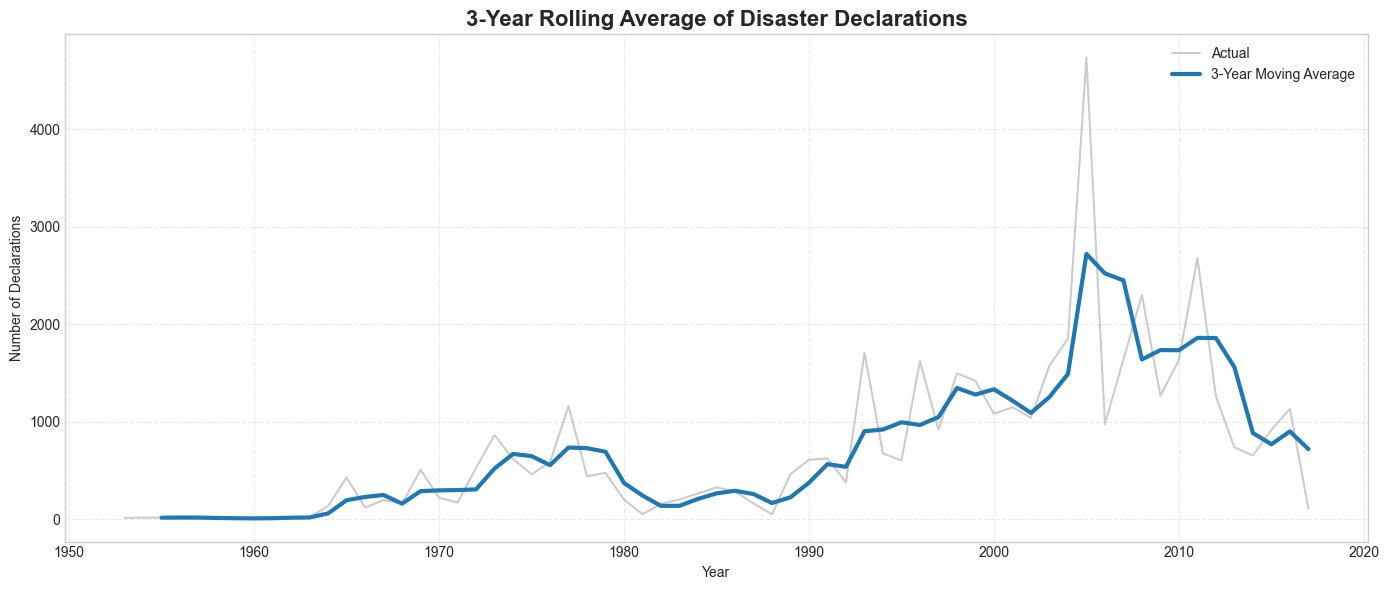

In [53]:
yearly_disasters = df.groupby('year').size()

rolling_3 = yearly_disasters.rolling(window=3).mean()

plt.figure(figsize=(14,6))

plt.plot(yearly_disasters.index, yearly_disasters.values,
         alpha=0.4, label="Actual",color="grey")

plt.plot(rolling_3.index, rolling_3.values,
         linewidth=3, label="3-Year Moving Average")

plt.title("3-Year Rolling Average of Disaster Declarations",
          fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

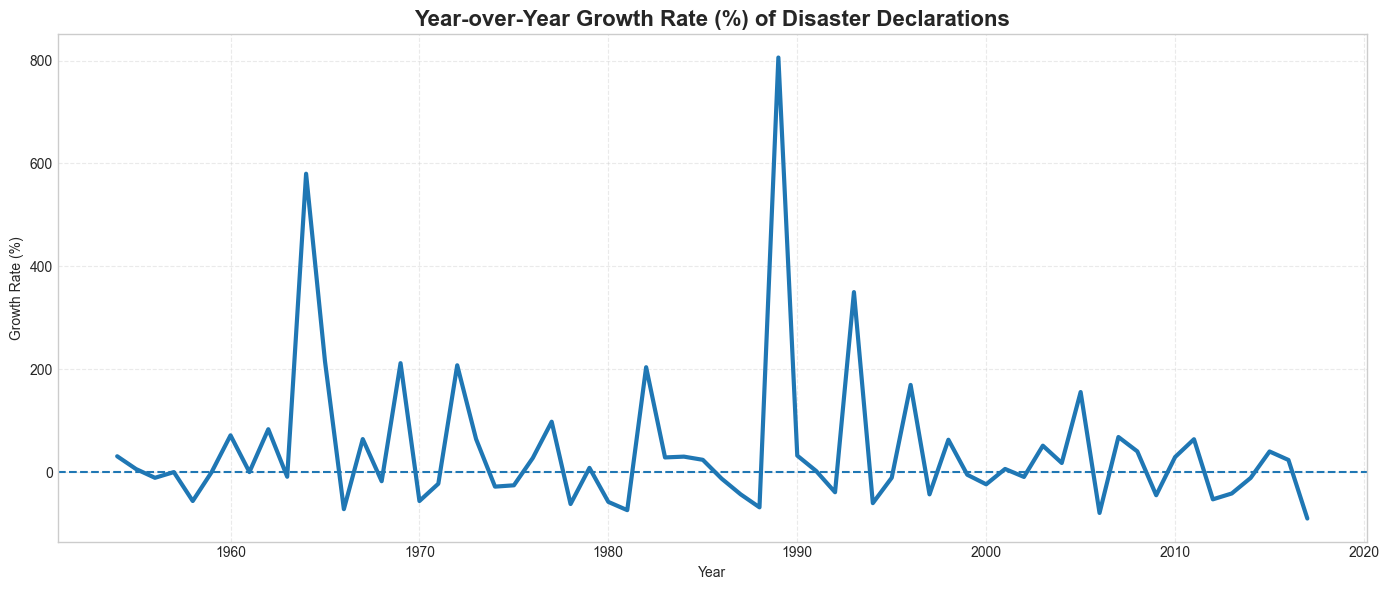

In [48]:
growth_rate = yearly_disasters.pct_change() * 100

plt.figure(figsize=(14,6))

plt.plot(growth_rate.index, growth_rate.values,
         linewidth=3)

plt.axhline(0, linestyle='--')

plt.title("Year-over-Year Growth Rate (%) of Disaster Declarations",
          fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Top 5 Peak Disaster Years:
year
2005    4736
2011    2680
2008    2300
2004    1853
1993    1705
dtype: int64


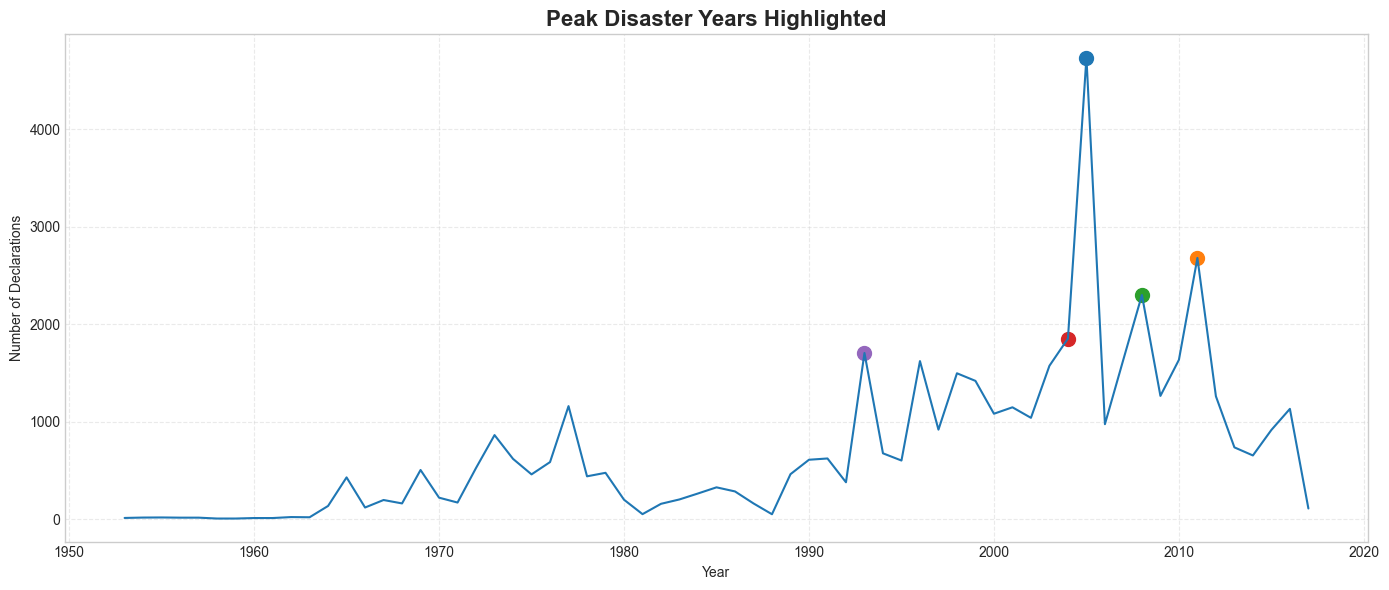

In [55]:
top_years = yearly_disasters.sort_values(ascending=False).head(5)

print("Top 5 Peak Disaster Years:")
print(top_years)
plt.figure(figsize=(14,6))

plt.plot(yearly_disasters.index, yearly_disasters.values)

for year in top_years.index:
    plt.scatter(year, yearly_disasters[year], s=100)

plt.title("Peak Disaster Years Highlighted",
          fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()